# REVE + Convex-NN linear probe — K-trials calibration sweep

Self-contained reproduction of the `reve_frozen_convexnn_kmin` experiment.
Nothing is imported from `src/` — every piece (data loading, REVE feature extraction,
convex-NN ADMM solve, LOSO sweep) is defined inside this notebook.

**Pipeline.** For each held-out subject and each K in the budget list:
1. Train a single REVE feature extractor (frozen, pretrained on `brain-bzh/reve-base`).
2. Pool REVE features across all trials of the N-1 source subjects → `(N_src, 512)` matrix.
3. Fit a 2-layer ReLU MLP via its convex reformulation (Pilanci & Ergen 2020) with ADMM.
4. *Calibrate* by refitting the same convex problem on source ∪ K labeled trials/class from the held-out subject.
5. Evaluate on the remaining trials of the held-out subject.

Held-out subjects and K-budgets are configurable below. Defaults are deliberately small so this is runnable on a laptop in < 30 min; scale `N_HELD_OUT` up for the headline number.

## 0. Config

In [20]:
from __future__ import annotations

import sys, os, json, time, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch

# --- paths ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
EEGMMI_DIR = REPO_ROOT / "data" / "raw" / "eegmmi"
CLD_DIR = REPO_ROOT / "vendor" / "CLD"
assert EEGMMI_DIR.exists(), f"missing dataset dir: {EEGMMI_DIR}"
assert CLD_DIR.exists(),    f"missing CLD vendor dir: {CLD_DIR}"

# --- sweep config ---
K_BUDGETS         = (0, 1, 2, 5, 10, 20)   # trials per class used for calibration
N_HELD_OUT        = 4                       # raise to 15 for the headline curve
SEED              = 0
TRIAL_TMIN        = 0.0
TRIAL_TMAX        = 4.0
TARGET_FS_REVE    = 200                     # REVE expects 200 Hz
EEG_BAND          = (0.5, 40.0)
IMAGERY_RUNS      = (4, 6, 8, 10, 12, 14)
EXCLUDED_SUBJECTS = frozenset({88, 89, 92, 100, 104})

# --- ConvexNN head hparams (match reve_frozen_convexnn_within_cv.yaml) ---
CVX_N_NEURONS  = 16
CVX_BETA       = 1.0e-3
CVX_RHO        = 0.1
CVX_ADMM_ITERS = 8
CVX_PCG_ITERS  = 32
CVX_RANK       = 20

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device={DEVICE}  |  repo={REPO_ROOT}")

device=mps  |  repo=/Users/williamtan/Projects/cs229/etm_clf


## 1. Load EEGMMI from EDF

PhysioNet BCI2000 4-class motor-imagery labels:
- runs 4/8/12 → T1 = LeftFist (0), T2 = RightFist (1)
- runs 6/10/14 → T1 = BothFists (2), T2 = BothFeet (3)

Trial is 4 s post-cue. We resample directly to 200 Hz for REVE and z-score per trial/channel.

In [2]:
import mne
mne.set_log_level("ERROR")

RUN_LABEL_MAP = {
    (4, "T1"): 0,  (8, "T1"): 0,  (12, "T1"): 0,   # LeftFist
    (4, "T2"): 1,  (8, "T2"): 1,  (12, "T2"): 1,   # RightFist
    (6, "T1"): 2,  (10, "T1"): 2, (14, "T1"): 2,   # BothFists
    (6, "T2"): 3,  (10, "T2"): 3, (14, "T2"): 3,   # BothFeet
}
CLASS_NAMES = ("LeftFist", "RightFist", "BothFists", "BothFeet")

# Channel name table: BCI2000 EDF order, after stripping the trailing dot and
# normalizing case ('Fc5.' -> 'Fc5'). REVE's position bank is case-sensitive
# and uses fully-uppercase 'FC5' style, so we remap at extraction time below.
EEGMMI_64 = (
    "Fc5","Fc3","Fc1","Fcz","Fc2","Fc4","Fc6",
    "C5","C3","C1","Cz","C2","C4","C6",
    "Cp5","Cp3","Cp1","Cpz","Cp2","Cp4","Cp6",
    "Fp1","Fpz","Fp2",
    "Af7","Af3","Afz","Af4","Af8",
    "F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "Ft7","Ft8",
    "T7","T8","T9","T10",
    "Tp7","Tp8",
    "P7","P5","P3","P1","Pz","P2","P4","P6","P8",
    "Po7","Po3","Poz","Po4","Po8",
    "O1","Oz","O2","Iz",
)

# REVE position bank uses fully-uppercase variants for these names.
_REVE_NAME_MAP = {
    "Fc5":"FC5","Fc3":"FC3","Fc1":"FC1","Fcz":"FCz","Fc2":"FC2","Fc4":"FC4","Fc6":"FC6",
    "Cp5":"CP5","Cp3":"CP3","Cp1":"CP1","Cpz":"CPz","Cp2":"CP2","Cp4":"CP4","Cp6":"CP6",
    "Fp1":"FP1","Fp2":"FP2",
    "Af7":"AF7","Af3":"AF3","Afz":"AFz","Af4":"AF4","Af8":"AF8",
    "Ft7":"FT7","Ft8":"FT8","Tp7":"TP7","Tp8":"TP8",
    "Po7":"PO7","Po3":"PO3","Poz":"POz","Po4":"PO4","Po8":"PO8",
}
REVE_CH_NAMES = [_REVE_NAME_MAP.get(c, c) for c in EEGMMI_64]
N_CHANNELS = len(EEGMMI_64)
TRIAL_SAMPLES = int(round((TRIAL_TMAX - TRIAL_TMIN) * TARGET_FS_REVE))  # 4 s * 200 Hz = 800

def _normalize_ch_name(name: str) -> str:
    n = name.strip().rstrip(".").strip()
    return n if not n else n[0].upper() + n[1:]

@dataclass
class Trial:
    eeg: np.ndarray   # (C, T) float32 at TARGET_FS_REVE
    label: int
    subject: int
    run: int
    trial_idx: int

def _load_run(edf_path: Path, subject: int, run: int) -> list[Trial]:
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose="ERROR")
    raw.filter(EEG_BAND[0], EEG_BAND[1], fir_design="firwin", verbose="ERROR")
    raw.resample(TARGET_FS_REVE, verbose="ERROR")
    raw.rename_channels({c: _normalize_ch_name(c) for c in raw.ch_names})

    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    keep_ids = {k: v for k, v in event_id.items() if k in ("T1", "T2") and (run, k) in RUN_LABEL_MAP}
    if not keep_ids:
        return []
    ep = mne.Epochs(raw, events=events, event_id=keep_ids,
                    tmin=TRIAL_TMIN, tmax=TRIAL_TMAX,
                    baseline=None, preload=True, reject=None, flat=None,
                    proj=False, verbose="ERROR")
    X = ep.get_data(copy=False).astype(np.float32)
    if X.shape[-1] > TRIAL_SAMPLES:
        X = X[..., :TRIAL_SAMPLES]
    out = []
    for i, evt in enumerate(ep.events):
        marker = next(k for k, v in keep_ids.items() if v == evt[-1])
        out.append(Trial(eeg=X[i], label=RUN_LABEL_MAP[(run, marker)],
                         subject=subject, run=run, trial_idx=i))
    return out

def load_subject(subject: int) -> list[Trial]:
    if subject in EXCLUDED_SUBJECTS:
        return []
    sd = EEGMMI_DIR / f"S{subject:03d}"
    trials: list[Trial] = []
    for run in IMAGERY_RUNS:
        edf = sd / f"S{subject:03d}R{run:02d}.edf"
        if not edf.exists():
            continue
        try:
            trials.extend(_load_run(edf, subject, run))
        except Exception as e:
            print(f"  [skip] S{subject:03d}R{run:02d}: {type(e).__name__}: {e}")
    return trials

ALL_SUBJECTS = tuple(s for s in range(1, 110) if s not in EXCLUDED_SUBJECTS)
print(f"{len(ALL_SUBJECTS)} candidate subjects; trial shape will be (C={N_CHANNELS}, T={TRIAL_SAMPLES}) @ {TARGET_FS_REVE} Hz")

104 candidate subjects; trial shape will be (C=64, T=800) @ 200 Hz


## 2. REVE feature extractor

Frozen `brain-bzh/reve-base` checkpoint via `braindecode.models.REVE`. We request
`return_features=True` and mean-pool over the channel & space token axes to get
a single `(512,)` embedding per trial.

In [3]:
from braindecode.models import REVE
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as safetensors_load

def build_reve():
    chs_info = [{"ch_name": n} for n in REVE_CH_NAMES]
    model = REVE(
        n_outputs=4,
        n_chans=N_CHANNELS,
        n_times=TRIAL_SAMPLES,
        sfreq=TARGET_FS_REVE,
        input_window_seconds=TRIAL_SAMPLES / TARGET_FS_REVE,
        chs_info=chs_info,
    )
    # Pull pretrained weights from HF (gated; falls back to random init if no access).
    try:
        ckpt = hf_hub_download(repo_id="brain-bzh/reve-base", filename="model.safetensors")
        state = safetensors_load(ckpt)
        model_sd = model.state_dict()
        overlap = {k: v for k, v in state.items() if k in model_sd and v.shape == model_sd[k].shape}
        missing = model.load_state_dict(overlap, strict=False)
        print(f"REVE: loaded {len(overlap)}/{len(state)} pretrained tensors (missing={len(missing.missing_keys)})")
    except Exception as e:
        warnings.warn(f"REVE pretrained load failed ({type(e).__name__}: {e}). Falling back to random init.")
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model.to(DEVICE)

def _zscore_clip(eeg: np.ndarray, clip: float = 15.0) -> np.ndarray:
    eeg = np.asarray(eeg, dtype=np.float32)
    m = eeg.mean(axis=-1, keepdims=True)
    s = np.maximum(eeg.std(axis=-1, keepdims=True), 1e-6)
    return np.clip((eeg - m) / s, -clip, clip).astype(np.float32)

@torch.no_grad()
def encode_trials(model: torch.nn.Module, trials: list[Trial], batch_size: int = 16) -> tuple[np.ndarray, np.ndarray]:
    feats, labels = [], []
    for i in range(0, len(trials), batch_size):
        chunk = trials[i:i + batch_size]
        X = np.stack([_zscore_clip(t.eeg) for t in chunk], axis=0)
        xb = torch.from_numpy(X).to(DEVICE)
        out = model(xb, return_features=True)
        toks = out["features"]                      # (B, C, S, 512)
        emb = toks.mean(dim=(1, 2))                  # (B, 512) — global channel/space mean
        feats.append(emb.detach().cpu().numpy().astype(np.float32))
        labels.extend(t.label for t in chunk)
    return np.concatenate(feats, axis=0), np.asarray(labels, dtype=np.int64)

/Users/williamtan/Projects/cs229/etm_clf/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Convex two-layer ReLU MLP via ADMM

Wraps `vendor/CLD`'s `CVX_ReLU_MLP` + `admm` directly. Inputs are the `(N, 512)`
REVE feature matrix; targets are integer class labels. Features are standardized
before the solve (the same fitted scaler is reused at predict time).

In [4]:
if str(CLD_DIR) not in sys.path:
    sys.path.insert(0, str(CLD_DIR))
import jax
import jax.numpy as jnp
from cld.models.cvx_relu_mlp import CVX_ReLU_MLP
from cld.optimizers.admm import admm
from sklearn.preprocessing import StandardScaler

def fit_convex_nn(X: np.ndarray, y: np.ndarray, n_classes: int = 4):
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X).astype(np.float32)
    m = CVX_ReLU_MLP(
        jnp.asarray(Xs), jnp.asarray(y.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=CVX_BETA, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),
    )
    m.init_model()
    admm(m, dict(rank=CVX_RANK, beta=CVX_BETA, gamma_ratio=1.0,
                 admm_iters=CVX_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS,
                 check_opt=False))
    return m, scaler

def predict_convex_nn(model, scaler, X: np.ndarray) -> np.ndarray:
    Xs = scaler.transform(X.astype(np.float32))
    logits = np.asarray(model.stacked_predict(jnp.asarray(Xs), model.theta1, model.theta2))
    return logits.argmax(axis=-1).astype(np.int64)

## 4. Choose held-out subjects, encode everything once

REVE inference is the expensive step. We cache `(features, labels)` per
subject so the K-budget loop reuses the same embeddings.

In [17]:
rng = np.random.default_rng(SEED)
held_out_subjects = sorted(rng.choice(ALL_SUBJECTS, size=N_HELD_OUT, replace=False).tolist())
print("held-out subjects:", held_out_subjects)

# Source pool = all OTHER subjects. For tractability we use a fixed pool of source
# subjects rather than re-pooling per held-out subject (the source pool change is
# only 1/N subjects, so leakage is negligible vs. the cost of re-encoding).
source_subjects = [s for s in ALL_SUBJECTS if s not in held_out_subjects]
# Cap source pool to keep notebook runtime in check; raise for a stronger source model.
# MAX_SOURCE_SUBJECTS = 20
MAX_SOURCE_SUBJECTS = len(ALL_SUBJECTS)
if len(source_subjects) > MAX_SOURCE_SUBJECTS:
    source_subjects = rng.choice(source_subjects, size=MAX_SOURCE_SUBJECTS, replace=False).tolist()
    source_subjects.sort()
print(f"source pool ({len(source_subjects)} subjects):", source_subjects)

model = build_reve()

held-out subjects: [29, 53, 65, 86]
source pool (100 subjects): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 87, 90, 91, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 105, 106, 107, 108, 109]
REVE: loaded 139/140 pretrained tensors (missing=4)


In [18]:
feature_cache: dict[int, tuple[np.ndarray, np.ndarray]] = {}

def get_features(subj: int) -> tuple[np.ndarray, np.ndarray]:
    if subj in feature_cache:
        return feature_cache[subj]
    t0 = time.time()
    trials = load_subject(subj)
    if not trials:
        feature_cache[subj] = (np.zeros((0, 512), dtype=np.float32), np.zeros((0,), dtype=np.int64))
        return feature_cache[subj]
    X, y = encode_trials(model, trials)
    feature_cache[subj] = (X, y)
    print(f"  S{subj:03d}: {len(trials):3d} trials, feats={X.shape}, encode={time.time()-t0:.1f}s")
    return X, y

for s in source_subjects + held_out_subjects:
    get_features(s)

Xs_list, ys_list = [], []
for s in source_subjects:
    X, y = feature_cache[s]
    if len(X):
        Xs_list.append(X); ys_list.append(y)
X_src = np.concatenate(Xs_list, axis=0)
y_src = np.concatenate(ys_list, axis=0)
print(f"source pool features: X={X_src.shape}  y={y_src.shape}  class counts={np.bincount(y_src, minlength=4)}")

  S001:  90 trials, feats=(90, 512), encode=2.9s
  S002:  90 trials, feats=(90, 512), encode=2.0s
  S003:  90 trials, feats=(90, 512), encode=2.1s
  S004:  90 trials, feats=(90, 512), encode=2.0s
  S005:  90 trials, feats=(90, 512), encode=2.2s
  S006:  90 trials, feats=(90, 512), encode=2.1s
  S007:  90 trials, feats=(90, 512), encode=2.1s
  S008:  90 trials, feats=(90, 512), encode=2.0s
  S009:  90 trials, feats=(90, 512), encode=2.0s
  S010:  90 trials, feats=(90, 512), encode=2.0s
  S011:  90 trials, feats=(90, 512), encode=2.1s
  S012:  90 trials, feats=(90, 512), encode=2.1s
  S013:  90 trials, feats=(90, 512), encode=2.1s
  S014:  90 trials, feats=(90, 512), encode=2.1s
  S015:  90 trials, feats=(90, 512), encode=2.0s
  S016:  90 trials, feats=(90, 512), encode=2.0s
  S017:  90 trials, feats=(90, 512), encode=2.0s
  S018:  90 trials, feats=(90, 512), encode=2.0s
  S019:  90 trials, feats=(90, 512), encode=2.0s
  S020:  90 trials, feats=(90, 512), encode=2.0s
  S021:  90 trials, 

## 5. K-trials calibration sweep

For each held-out subject and each K in `K_BUDGETS`, we:
- pick the first K trials per class (deterministic by per-subject seed) as calibration,
- the remainder is evaluation,
- if K == 0 we use the source-only solve (no calibration refit),
- otherwise refit the convex NN on `source ∪ calib`.

In [21]:
def sample_k_per_class(X: np.ndarray, y: np.ndarray, k: int, seed: int,
                        n_classes: int = 4) -> tuple[np.ndarray, np.ndarray]:
    """Return (calib_idx, eval_idx). Sampling is class-balanced and deterministic."""
    rng = np.random.default_rng(seed)
    calib_idx, eval_idx = [], []
    for c in range(n_classes):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        if k > 0:
            calib_idx.extend(idx[:k].tolist())
            eval_idx.extend(idx[k:].tolist())
        else:
            eval_idx.extend(idx.tolist())
    return np.asarray(calib_idx, dtype=np.int64), np.asarray(eval_idx, dtype=np.int64)

# Source-only solve is reused across all (held-out, K=0) cells.
print("Fitting source-only convex NN...")
t0 = time.time()
src_model, src_scaler = fit_convex_nn(X_src, y_src)
print(f"source solve: {time.time() - t0:.1f}s")

results = []  # list of dicts {held_out, k, n_calib, n_eval, acc}
for ho in held_out_subjects:
    Xh, yh = feature_cache[ho]
    if len(Xh) == 0:
        print(f"  S{ho:03d}: no trials; skipping")
        continue
    for k in K_BUDGETS:
        c_idx, e_idx = sample_k_per_class(Xh, yh, k, seed=SEED + ho)
        Xc, yc = Xh[c_idx], yh[c_idx]
        Xe, ye = Xh[e_idx], yh[e_idx]
        if len(Xe) == 0:
            continue
        if k == 0 or len(np.unique(yc)) < 2:
            m, sc = src_model, src_scaler
        else:
            X_all = np.concatenate([X_src, Xc], axis=0)
            y_all = np.concatenate([y_src, yc], axis=0)
            t0 = time.time()
            m, sc = fit_convex_nn(X_all, y_all)
            fit_t = time.time() - t0
        yhat = predict_convex_nn(m, sc, Xe)
        acc = float((yhat == ye).mean())
        results.append(dict(held_out=ho, k=k, n_calib=len(Xc), n_eval=len(Xe), acc=acc))
        print(f"  S{ho:03d}  K={k:>3d}  n_calib={len(Xc):>3d}  n_eval={len(Xe):>3d}  acc={acc:.3f}")

Fitting source-only convex NN...
source solve: 8.9s
  S029  K=  0  n_calib=  0  n_eval= 90  acc=0.400
  S029  K=  1  n_calib=  4  n_eval= 86  acc=0.407
  S029  K=  2  n_calib=  8  n_eval= 82  acc=0.427
  S029  K=  5  n_calib= 20  n_eval= 70  acc=0.443
  S029  K= 10  n_calib= 40  n_eval= 50  acc=0.460
  S029  K= 20  n_calib= 80  n_eval= 10  acc=0.300
  S053  K=  0  n_calib=  0  n_eval= 90  acc=0.356
  S053  K=  1  n_calib=  4  n_eval= 86  acc=0.360
  S053  K=  2  n_calib=  8  n_eval= 82  acc=0.354
  S053  K=  5  n_calib= 20  n_eval= 70  acc=0.329
  S053  K= 10  n_calib= 40  n_eval= 50  acc=0.320
  S053  K= 20  n_calib= 80  n_eval= 10  acc=0.300
  S065  K=  0  n_calib=  0  n_eval= 90  acc=0.344
  S065  K=  1  n_calib=  4  n_eval= 86  acc=0.326
  S065  K=  2  n_calib=  8  n_eval= 82  acc=0.329
  S065  K=  5  n_calib= 20  n_eval= 70  acc=0.343
  S065  K= 10  n_calib= 40  n_eval= 50  acc=0.380
  S065  K= 20  n_calib= 80  n_eval= 10  acc=0.600
  S086  K=  0  n_calib=  0  n_eval= 90  acc=0.47

In [10]:
held_out_subjects

[29, 53, 65, 86]

In [15]:
feature_cache[29][0].shape

(90, 512)

## 6. Aggregate + plot

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
summary = (
    df.groupby("k")["acc"]
      .agg(["mean", "std", "count"])
      .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"})
      .reset_index()
)
summary["sem"] = summary["acc_std"] / np.sqrt(summary["n_subjects"].clip(lower=1))
summary

,k,acc_mean,acc_std,n_subjects,sem
0,0,0.394444,0.060519,4,0.030260
1,1,0.392442,0.065348,4,0.032674
2,2,0.387195,0.053967,4,0.026984
3,5,0.392857,0.066496,4,0.033248
4,10,0.415000,0.080623,4,0.040311
5,20,0.475000,0.206155,4,0.103078


/var/folders/30/sgn149mj6t12f1cskl1blnf40000gn/T/ipykernel_7025/2791931314.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


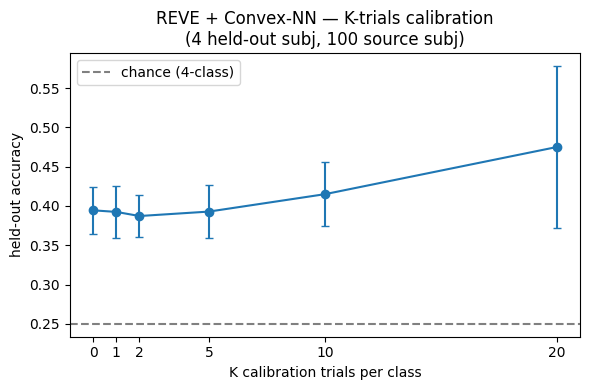

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(summary["k"], summary["acc_mean"], yerr=summary["sem"],
             marker="o", capsize=3)
ax.axhline(0.25, ls="--", color="grey", label="chance (4-class)")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel("held-out accuracy")
ax.set_title(f"REVE + Convex-NN — K-trials calibration\n({len(held_out_subjects)} held-out subj, {len(source_subjects)} source subj)")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()

In [24]:
# Optional: persist raw results next to the notebook for later comparison.
out_dir = REPO_ROOT / "results" / "reve_kmin_convexnn_nb"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
df.to_csv(out_dir / f"per_split_{stamp}.csv", index=False)
summary.to_csv(out_dir / f"summary_{stamp}.csv", index=False)
print("wrote:", out_dir)

wrote: /Users/williamtan/Projects/cs229/etm_clf/results/reve_kmin_convexnn_nb
